## **📄 Evaluating AI Medical Note Summarization Applications**

In clinical settings, summarizing medical notes is a critical task that can be significantly improved with AI applications. However, ensuring the **accuracy**, **coherence**, and **safety** of AI-generated summaries is essential before clinical integration. This use case focuses on evaluating AI models for medical note summarization, following the **MedHELM** framework to ensure that outputs meet clinical standards for quality and safety.

## **Medical Summarization Task**

Medical doctors currently spend between **52 to 102 minutes per day** writing clinical notes after patient encounters. These notes document visit discussions, diagnoses, test orders, and treatments. While crucial for healthcare delivery, billing, and legal documentation, this administrative burden—an unintended consequence of the **HITECH Act (2009)**—has become a major contributor to **physician fatigue** and **burnout**. Hiring **medical scribes** has been one solution, but this can cost up to **$112,000 annually** depending on specialty and institution. High attrition rates and specialized training requirements further limit scalability. With the advent of **large language models (LLMs)**, **automatic clinical note generation** is emerging as a promising alternative to reduce physician workload, improve efficiency, and enhance care quality.

However, to responsibly develop and evaluate these AI solutions, **high-quality, representative datasets** are needed. Clinical data is often scarce and highly protected due to ethical and legal concerns. For this project, we will use the **ACI-Bench** dataset — a synthetic yet clinically realistic corpus of full visit dialogues and corresponding clinical notes — to benchmark and evaluate model performance.

> **Note**: Although the broader corpus also includes the **MTS-Dialog** dataset, **we will only use ACI-Bench** for our evaluation.  
> ACI-Bench is more aligned with our goals because it contains **full visit dialogues**, **comprehensive clinical notes**, and **rich metadata** (e.g., patient age, gender), offering a closer simulation of real-world clinical encounters.

### **⚙️ What We’ll Build**

An end‑to‑end medical note‑summarization application that tests multiple large language models (LLMs) and systematically benchmarks their ability to generate concise, clinically accurate visit notes.

**Key Steps**  
1. **Model Selection** — compare GPT‑4o, O1, Phi‑3, Phi‑4, and other state‑of‑the‑art models.  
2. **Find Dataset** — map summarization tasks to established clinical taxonomies and Datasets.  
3. **Evaluation Methods** — blend rule‑based validation with LLM‑as‑Judge assessments.  
5. **Leaderboard & Visualization** — surface results in an interactive dashboard (Azure AI Foundry or a custom Streamlit app).

**Why It Matters**  
A rigorous, transparent evaluation pipeline protects patient safety, lightens clinicians’ documentation burden, and accelerates the responsible adoption of AI in healthcare.

### **📚 Dataset Overview**

- **ACI-Bench**:  
  - Full visit dialogues between clinician and patient.  
  - Complete clinical notes paired with the dialogues.  
  - Metadata such as patient age, gender, and name.  
  - Synthetic data curated by medical annotators and clinicians.

The **ACI-Bench** dataset has been used in major international research challenges, including:

- [MEDIQA-CHAT 2023 @ ACL CLINICALNLP](https://sites.google.com/view/mediqa2023/clinicalnlp-mediqa-chat-2023)
- [MEDIQA-SUM 2023 @ CLEF](https://www.imageclef.org/2023/medical/mediqa)

This dataset enables responsible experimentation and benchmarking for AI models focused on clinical note generation.

### **📝 Papers**

**ACI-BENCH: A Novel Ambient Clinical Intelligence Dataset for Benchmarking Automatic Visit Note Generation**  
Authors: Wen-wai Yim, Yujuan Fu, Asma Ben Abacha, Neal Snider, Thomas Lin, Meliha Yetisgen  
[Paper Link](https://www.nature.com/articles/s41597-023-02487-3)

```bibtex
@article{aci-bench,
  author  = {Wen-wai Yim and Yujuan Fu and Asma Ben Abacha and Neal Snider and Thomas Lin and Meliha Yetisgen},
  title   = {ACI-BENCH: a Novel Ambient Clinical Intelligence Dataset for Benchmarking Automatic Visit Note Generation},
  journal = {Nature Scientific Data},
  year    = {2023},
  volume  = {10},
  url     = {https://www.nature.com/articles/s41597-023-02487-3}
}
```


## **1. Choosing the Candidate LLMs**

As I navigated the Azure AI Foundry catalog, a plethora of AI models unfolded, each with unique capabilities. My past successes with Azure OpenAI models naturally directed my focus towards them for my current endeavor: offline medical note summarization.​

Given the offline nature of this application, real-time processing isn't a necessity. Therefore, my primary concern shifts from latency to the quality of the output. Cost-effectiveness remains a consideration, but the accuracy and coherence of the generated summaries are paramount.​


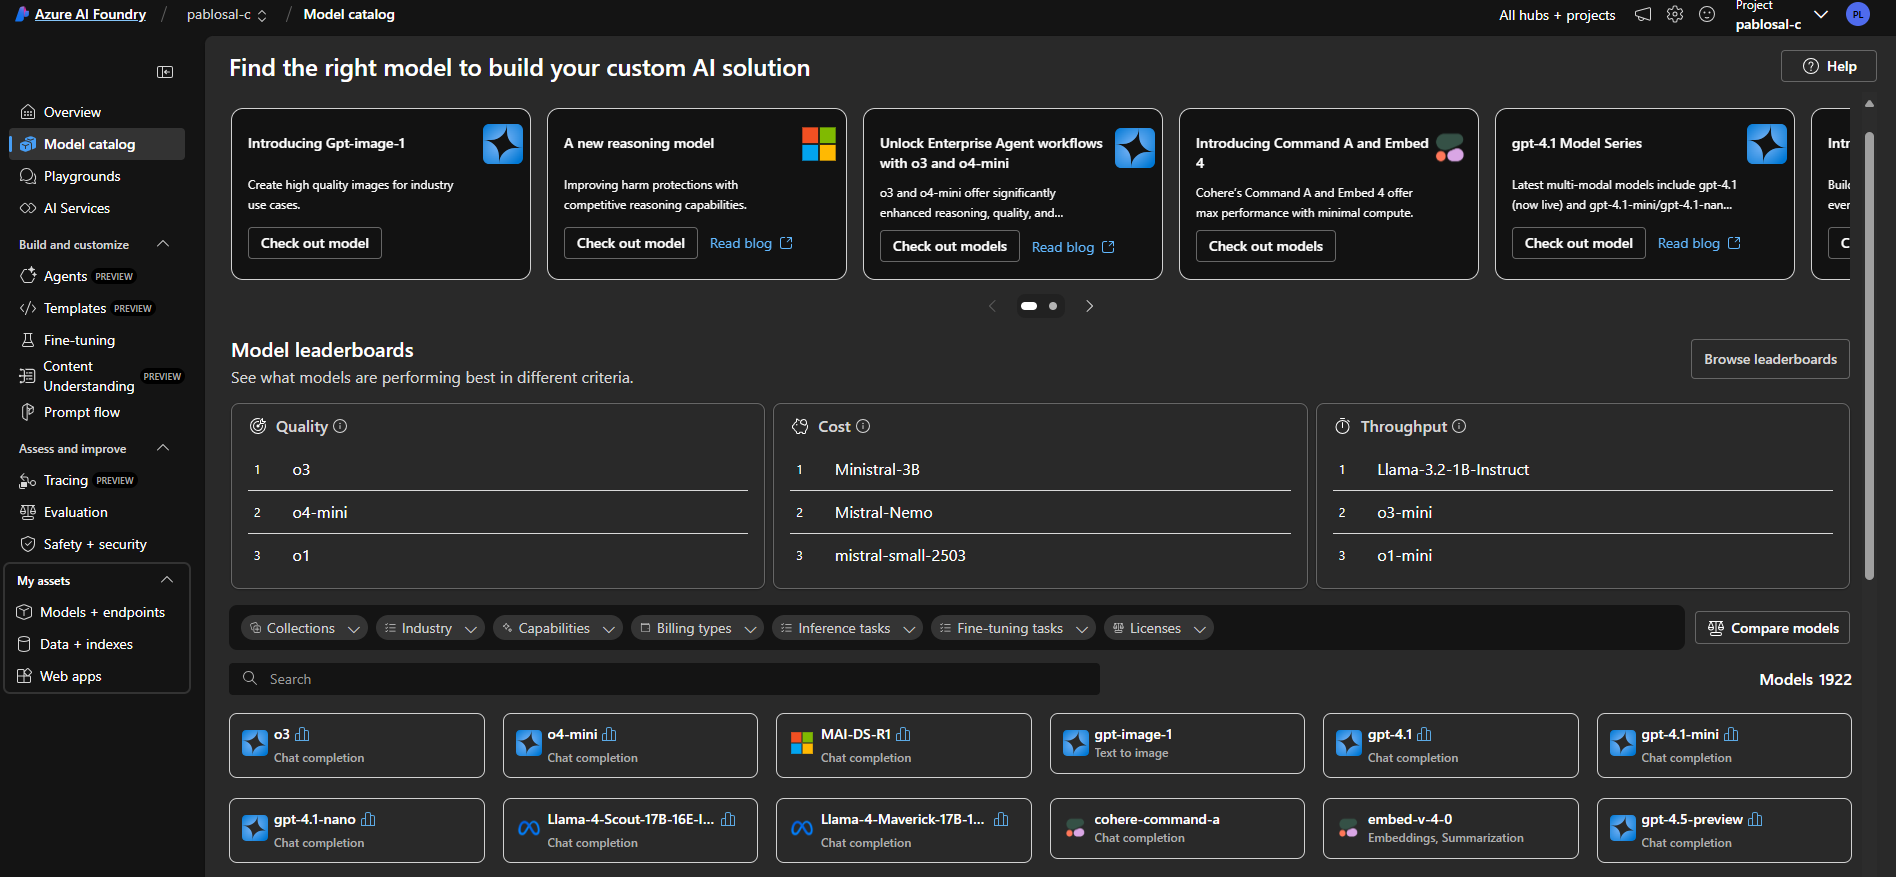

With these priorities in mind, I've shortlisted the following models for evaluation:​

+ **GPT-4o**: Renowned for its high-quality outputs, GPT-4o offers advanced capabilities, including multimodal processing. However, these features come with higher costs and latency, which might be excessive for an offline application.​

- **GPT-4o Mini**: A streamlined version of GPT-4o, this model balances performance and cost. It boasts a 128K token context window and has demonstrated superior performance on benchmarks like MMLU, scoring 82% compared to GPT-3.5 Turbo's 70%. Additionally, it's more than 60% cost-effective than GPT-3.5 Turbo, making it a compelling choice for applications where quality and cost are both crucial considerations. ​

- **GPT-4.1 Nano**: The latest addition to the GPT series, GPT-4.1 Nano is designed for low latency and cost. It supports a context window of up to 1 million tokens, significantly surpassing its predecessors. This model is tailored for applications requiring efficient processing of large datasets, making it suitable for offline medical note summarization.​

+ **o4-mini**: This model is optimized for reasoning tasks, such as mathematical problem-solving and logical reasoning. Including o4-mini in the evaluation allows for a comparison between instruction-following models and those designed for reasoning, providing insights into their respective performances in medical note summarization. ​
GeeksforGeeks


By evaluating these models, I aim to identify the one that offers the best balance between quality and cost for my specific use case. The advancements in GPT-4.1 Nano, particularly its expansive context window and cost-efficiency, make it a promising candidate for applications like mine.

In [1]:
import os
import time
from typing import List, Dict, Tuple
from openai import AzureOpenAI
from dotenv import load_dotenv

load_dotenv()

import logging
logger = logging.getLogger(__name__)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)

# We begin our journey by loading the secret keys from the environment...
ENDPOINT: str = os.getenv("AZURE_OPENAI_ENDPOINT") or ""
API_VERSION: str = "2024-12-01-preview"
SUBSCRIPTION_KEY: str = os.getenv("AZURE_OPENAI_KEY") or ""

if not SUBSCRIPTION_KEY:
    raise ValueError("Please set the AZURE_OPENAI_KEY environment variable.")
if not ENDPOINT:
    raise ValueError("Please set the AZURE_OPENAI_ENDPOINT environment variable.")

# Here we map conversational aliases to actual Azure deployment identifiers.
MODEL_CONFIGS: Dict[str, str] = {
    "gpt-4o": "gpt-4o",
    "gpt-4o-mini": "gpt-4o-mini",
    "gpt-4.1-nano": "gpt-4.1-nano",
    "o4-mini": "o4-mini", 
}

# Client Initialization 
def get_openai_client() -> AzureOpenAI:
    """
    Initialize and return an Azure OpenAI client.
    """
    logger.info("Initializing Azure OpenAI client.")
    return AzureOpenAI(
        api_version=API_VERSION,
        azure_endpoint=ENDPOINT,
        api_key=SUBSCRIPTION_KEY,
    )


# Instruction-following Models
def call_chat_model(
    client: AzureOpenAI,
    model_key: str,
    messages: List[Dict[str, str]],
    max_tokens: int = 1024,
    temperature: float = 1.0,
    top_p: float = 1.0,
) -> Tuple[str, float]:
    """
    Call instruction-following models and measure end-to-end latency.
    Returns:
      - response text
      - latency in seconds
    """
    deployment = MODEL_CONFIGS[model_key]
    logger.info("Calling chat model '%s'...", deployment)
    start = time.time()

    try:
        response = client.chat.completions.create(
            messages=messages,
            max_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p,
            model=deployment,
        )
    except Exception as e:
        logger.exception("Chat model call failed for model '%s': %s", deployment, e)
        raise

    latency = time.time() - start
    logger.info("Model '%s' responded in %.2fs", deployment, latency)
    return response.choices[0].message.content, latency


# Reasoning-optimized Models 
def call_reasoning_model(
    client: AzureOpenAI,
    model_key: str,
    messages: List[Dict[str, str]],
    max_completion_tokens: int = 100000,
) -> Tuple[str, float]:
    """
    Call reasoning-optimized models (use max_completion_tokens) and measure latency.
    Returns:
      - response text
      - latency in seconds
    """
    deployment = MODEL_CONFIGS[model_key]
    logger.info("Calling reasoning model '%s'...", deployment)
    start = time.time()

    try:
        response = client.chat.completions.create(
            messages=messages,
            max_completion_tokens=max_completion_tokens,
            model=deployment,
        )
    except Exception as e:
        logger.exception("Reasoning model call failed for model '%s': %s", deployment, e)
        raise

    latency = time.time() - start
    logger.info("Model '%s' responded in %.2fs", deployment, latency)
    return response.choices[0].message.content, latency


client: AzureOpenAI = get_openai_client()

test_messages: List[Dict[str, str]] = [
    {
        "role": "system",
        "content": (
            "You are a medical scribe assistant. "
            "The following is a very messy, run-on clinical consultation note. "
            "Please clarify the key medical findings and then summarize it into a clean SOAP note (Subjective, Objective, Assessment, Plan)."
        )
    },
    {
        "role": "user",
        "content": (
            "John Doe a 45 year old male with hx of hypertension and hyperlipidemia presents complaining of chest pressure "
            "and shortness of breath for the last three days episodes happen with climbing stairs lasting about 10 to 15 mins "
            "eased by rest and nitroglycerin one dose also noticed mild sweating no nausea vital signs today BP 150/92 HR 88 "
            "RR 18 T 98.6 SpO2 97% physical exam heart regular no murmurs chest wall tender lungs clear pulses equal labs "
            "ECG normal sinus no ST changes troponin slightly elevated 0.04 plan to get stress test continue aspirin statin "
            "increase lisinopril advise diet exercise follow up in one week"
        )
    }
]

# Testing our instruction-following model
chat_content, chat_latency = call_chat_model(
    client, "gpt-4o", test_messages, max_tokens=1000, temperature=0.7, top_p=1.0
)
print(f"GPT-4o says: {chat_content}")
print(f"GPT-4o latency: {chat_latency:.3f}s\n")

# Testing our reasoning model
reason_content, reason_latency = call_reasoning_model(
    client, "o4-mini", test_messages, max_completion_tokens=100000
)
print(f"O4-mini reasons: {reason_content}")
print(f"O4-mini latency: {reason_latency:.3f}s")


2025-04-28 08:10:26,448 [INFO] Initializing Azure OpenAI client.
2025-04-28 08:10:26,465 [INFO] Calling chat model 'gpt-4o'...
2025-04-28 08:10:31,211 [INFO] HTTP Request: POST https://aihubnw3478841489.openai.azure.com//openai/deployments/gpt-4o/chat/completions?api-version=2024-12-01-preview "HTTP/1.1 200 OK"
2025-04-28 08:10:31,218 [INFO] Model 'gpt-4o' responded in 4.75s
2025-04-28 08:10:31,219 [INFO] Calling reasoning model 'o4-mini'...


GPT-4o says: ### SOAP Note

**Patient Name:** John Doe  
**Age:** 45 years  
**Sex:** Male  

---

**Subjective:**  
The patient, with a history of hypertension and hyperlipidemia, reports experiencing chest pressure and shortness of breath for the past three days. Symptoms are triggered by exertion, such as climbing stairs, and last approximately 10-15 minutes. Symptoms are relieved with rest and one dose of nitroglycerin. Mild sweating was noted during these episodes, but there was no associated nausea.

---

**Objective:**  
- **Vital Signs:** BP 150/92, HR 88, RR 18, T 98.6°F, SpO2 97%.  
- **Physical Exam:**  
  - Heart: Regular rate and rhythm, no murmurs.  
  - Lungs: Clear to auscultation bilaterally.  
  - Chest wall: Tenderness noted.  
  - Pulses: Equal bilaterally.  
- **Labs:**  
  - ECG: Normal sinus rhythm, no ST changes.  
  - Troponin: Slightly elevated at 0.04.

---

**Assessment:**  
- Chest pressure and exertional dyspnea concerning for possible angina.  
- Elevated

2025-04-28 08:11:00,691 [INFO] HTTP Request: POST https://aihubnw3478841489.openai.azure.com//openai/deployments/o4-mini/chat/completions?api-version=2024-12-01-preview "HTTP/1.1 200 OK"
2025-04-28 08:11:00,696 [INFO] Model 'o4-mini' responded in 29.48s


O4-mini reasons: Key Medical Findings  
- Patient: John Doe, 45‑year‑old male  
- Past medical history: hypertension, hyperlipidemia  
- Chief complaint: three days of chest “pressure” and shortness of breath with exertion (climbing stairs)  
- Symptom characteristics: episodes last 10–15 minutes, relieved by rest and sublingual nitroglycerin; associated with mild sweating, no nausea or vomiting  
- Vital signs: BP 150/92 mmHg, HR 88 bpm, RR 18/min, T 98.6°F, SpO₂ 97% on room air  
- Physical exam: heart rate regular, no murmurs; chest wall mildly tender; lungs clear bilaterally; peripheral pulses equal  
- ECG: normal sinus rhythm, no ST‑segment or T‑wave changes  
- Cardiac enzymes: troponin I mildly elevated at 0.04 ng/mL (upper reference ~0.03)  
- Current medications: aspirin, statin, lisinopril (to be increased)  
- Plan: noninvasive stress testing, continue aspirin and statin, up‑titrate lisinopril, dietary and exercise counseling, follow‑up in one week  

SOAP Note  

Subjectiv

## **2. Find The Ground Truth (Dataset) — My “Reason-Backwards” Process**
> **Why ACI‑Bench and *not* dataset X?**  
> My answer follows MedHELM’s pillars of **(a) real‑world relevance, (b) multi‑metric rigor, (c) standardized replicability**.  
> Below is the exact decision pipeline— I followed.

#### **2.1 Start with the Task Taxonomy → then Search for Data**
1. **Enumerate real tasks.** MedHELM crowdsourced 121 clinician‑approved tasks across five categories.  
2. **Pick one high‑impact sub‑task.** *Clinical Note Generation* drains the most clinician time; automating it would reclaim entire clinic days.  
3. **Define the evaluation unit.** One visit transcript ➔ one complete SOAP note. Any benchmark must test that end‑to‑end behavior.

#### **2.2 Research Public Datasets Available**

**Auditor:** “Which corpora even qualify for end‑to‑end note generation?”  
**Me:** “We need (1) full visit dialogue, (2) a gold clinical note, (3) ≥ 200 cases, (4) public access, and (5) SOAP‑compatible formatting.”  

| Dataset        | Full dialogue + note | Public licence | ≥ 200 cases | SOAP‑ready | Verdict |
|----------------|----------------------|----------------|-------------|------------|---------|
| MTS‑Dialog     | ✗ (snippets only)    | ✓              | 1.7 k       | ✗          | ❌ Reject |
| Primock‑57     | ✓                    | ✓              | 57          | ✗          | ❌ Too small |
| MIMIC notes    | ✗ (no dialogue)      | Restricted     | 38 k        | n/a        | ❌ No dialogue |
| Private EHR    | ✓                    | ✗              | ✓           | varies     | ❌ PHI‑restricted |
| **ACI‑Bench**  | **✓**                | **CC‑BY‑4.0**  | **207**     | **✓**      | ✅ **Select** |

**Auditor:** “So ACI‑Bench is literally the only publicly available corpus that ticks every box.”  
**Me:** “Absolutely. ACI‑Bench not only meets every benchmark but exceeds our expectations—saving us the time and complexity of building a private dataset from scratch.”

#### **2.3 Map Task → Dataset → Benchmark Artefacts**

For the first experiment I’m sticking to a strictly zero-shot setup: one realistic instruction, no section-by-section prompts. Prompt engineering is a fascinating optimisation topic, but to establish a clean baseline I want every model to process exactly the same input.

+ **Single Prompt** – the ClinScribe-AI instruction shown below.
- **Models Under Test** – gpt-4o, gpt-4o-mini, gpt-4.1-nano, and the reasoning-tuned o3-mini.
+ **Run** – feed each ACI-Bench transcript once and capture the full SOAP note.
- **Later Layers** – after we see out-of-the-box behaviour, we’ll add evaluation metrics, prompt-tuning, and chain-of-thought comparisons.

This baseline tells us which model already “gets it right” before any prompt hacks—measuring genuine capability rather than prompt-engineering skill.

**SYSTEM**  
You are *ClinScribe‑AI*, a licensed medical scribe with 10 years of primary‑care experience.  
• Draft concise, clinically accurate notes for the attending physician.  
• If facts are missing, write “—” instead of hallucinating.  
• NEVER invent test results, patient identifiers, or medication doses.

**INSTRUCTIONS**  
1. Identify key findings → map to SOAP sections.  
2. Verify no unsupported data.  
3. Assemble final note exactly as instructed.

**USER**  
Summarize the following **doctor–patient conversation** into one clinical note with **exactly four section headers** (ALL‑CAPS, followed by a colon) in this order:

HISTORY OF PRESENT ILLNESS:  
PHYSICAL EXAM:  
RESULTS:  
ASSESSMENT AND PLAN:  

Insert a blank line *after* each header.  
Return nothing else—no explanations, no markdown.  

Conversation (delimited by ```):  
{{transcript_text}}

In [14]:
"""
This script demonstrates how to call both instruction-following and reasoning-optimized models using the Azure OpenAI API.
Run single-shot SOAP-note generation on a slice of ACI-Bench.
"""
import pandas as pd

# config 
MODEL_CONFIGS: Dict[str, str] = {
    "gpt-4o":       "gpt-4o",
    "gpt-4o-mini":  "gpt-4o-mini",
    "gpt-4.1-nano": "gpt-4.1-nano",
    "o4-mini":      "o4-mini",
}
REASONING_MODELS = {"o4-mini"}

MAX_TOKENS     = 5000      # generous for full-note
TEMPERATURE    = 0.5       # lower for more deterministic output
TOP_P          = 1.0
N_EXAMPLES     = 1         # how many rows of df to test

# ── prompt builder
SYSTEM_PROMPT = """\
You are ClinScribe-AI, a licensed medical scribe with 10 years of primary-care experience.
• Draft concise, clinically accurate notes for the attending physician.
• If facts are missing, write "—" instead of hallucinating.
• NEVER invent test results, patient identifiers, or medication doses.

INSTRUCTIONS:
1. Identify key findings → map to SOAP sections.
2. Verify no unsupported data.
3. Assemble final note exactly as instructed.
"""

USER_PROMPT = """\
Summarize the following doctor–patient conversation into one clinical note with **exactly four section headers** (ALL-CAPS, followed by a colon) in this order:

HISTORY OF PRESENT ILLNESS:
PHYSICAL EXAM:
RESULTS:
ASSESSMENT AND PLAN:

Insert a blank line after each header.
Return nothing else—no explanations, no markdown.

Conversation (delimited by ```):
{dialogue}
"""

def build_messages(dialogue: str) -> List[Dict[str, str]]:
    return [{"role": "user", "content": USER_PROMPT.format(dialogue=dialogue)}]

df_evals = pd.read_csv("usecases\data\ground_truth.csv").head(N_EXAMPLES)


In [15]:
from openai import AsyncAzureOpenAI
import asyncio

SUBSCRIPTION_KEY: str = os.getenv("AZURE_OPENAI_KEY") or ""

if not SUBSCRIPTION_KEY:
    raise ValueError("Please set the AZURE_OPENAI_KEY environment variable.")

async_client = AsyncAzureOpenAI(
    api_key=SUBSCRIPTION_KEY,
    azure_endpoint=ENDPOINT,
    api_version=API_VERSION,
)

async def call_chat_model_async(
    deployment: str,
    messages: List[Dict[str, str]],
    temperature: float = TEMPERATURE,
    top_p: float = TOP_P,
    max_tokens: int = MAX_TOKENS,
) -> Tuple[str, float]:
    """
    Async call to instruction‑following (chat) models with full
    error handling and latency tracking.
    """
    logger.info("Submitting async chat request to '%s'...", deployment)
    start = time.time()
    try:
        resp = await async_client.chat.completions.create(
            model=deployment,
            messages=messages,
            temperature=temperature,
            top_p=top_p,
            max_tokens=max_tokens,
        )
        latency = time.time() - start
        logger.info("Chat model '%s' responded in %.2f s", deployment, latency)
        return resp.choices[0].message.content, latency
    except Exception as e:
        latency = time.time() - start
        logger.exception(
            "Chat model '%s' failed after %.2f s: %s",
            deployment,
            latency,
            e,
        )
        raise


async def call_reasoning_model_async(
    deployment: str,
    messages: List[Dict[str, str]],
    max_completion_tokens: int = MAX_TOKENS,
) -> Tuple[str, float]:
    """
    Async call to reasoning‑optimized models with full
    error handling and latency tracking.
    """
    logger.info("Submitting async reasoning request to '%s'...", deployment)
    start = time.time()
    try:
        resp = await async_client.chat.completions.create(
            model=deployment,
            messages=messages,
            max_completion_tokens=max_completion_tokens,
        )
        latency = time.time() - start
        logger.info("Reasoning model '%s' responded in %.2f s", deployment, latency)
        return resp.choices[0].message.content, latency
    except Exception as e:
        latency = time.time() - start
        logger.exception(
            "Reasoning model '%s' failed after %.2f s: %s",
            deployment,
            latency,
            e,
        )
        raise


async def process_encounter(enc, models: Dict[str, str], records: List[Dict]):
    """
    For one encounter, fire off all model calls in parallel and
    record results.  Any individual failure is logged but does
    not abort the rest.
    """
    try:
        messages = build_messages(enc.dialogue)
    except Exception as e:
        logger.exception("Failed to build messages for encounter %s: %s", enc.encounter_id, e)
        return records

    tasks, keys = [], []
    for key, dep in models.items():
        keys.append(key)
        coro = (
            call_reasoning_model_async(dep, messages, 10000)
            if key in REASONING_MODELS
            else call_chat_model_async(dep, messages)
        )
        tasks.append(asyncio.create_task(coro))

    results = await asyncio.gather(*tasks, return_exceptions=True)

    for key, result in zip(keys, results):
        if isinstance(result, Exception):
            logger.error("Model %s failed on encounter %s: %s", key, enc.encounter_id, result)
            continue

        note, latency = result
        records.append(
            {
                "encounter_id": enc.encounter_id,
                "query": messages[0]['content'],
                "model": key,
                "latency_sec": latency,
                "response": note,
                "ground_truth": enc.note,
            }
        )
        logger.info("Completed %s for encounter %s in %.2f s", key, enc.encounter_id, latency)

    return records


In [16]:
import os
import json
import asyncio
from pathlib import Path
import pandas as pd
from typing import Dict

# Define your models
MODEL_CONFIGS: Dict[str, str] = {
    "gpt-4o": "gpt-4o",
    "gpt-4o-mini": "gpt-4o-mini",
    "gpt-4.1-nano": "gpt-4.1-nano",
    "o4-mini": "o4-mini",
}

# Define the target directory (change yours)
TARGET_DIRECTORY = r"C:\Users\pablosal\Desktop\aihlsignited-medevals"

# Check if the directory exists
if os.path.exists(TARGET_DIRECTORY):
    os.chdir(TARGET_DIRECTORY)
    print(f"Directory changed to {os.getcwd()}")
else:
    raise FileNotFoundError(f"Directory {TARGET_DIRECTORY} does not exist.")

# Load only the first 10 encounters
df = pd.read_csv("usecases/data/ground_truth.csv").head(10)

# Initialize records
records = []

# Build and run tasks
tasks = [process_encounter(row, MODEL_CONFIGS, records) for row in df.itertuples()]
records = await asyncio.gather(*tasks)

# Flatten if necessary
if any(isinstance(r, list) for r in records):
    flat_records = [item for sublist in records for item in sublist]
else:
    flat_records = records




2025-04-28 08:18:03,556 [INFO] Submitting async chat request to 'gpt-4o'...
2025-04-28 08:18:03,561 [INFO] Submitting async chat request to 'gpt-4o-mini'...


2025-04-28 08:18:03,567 [INFO] Submitting async chat request to 'gpt-4.1-nano'...
2025-04-28 08:18:03,573 [INFO] Submitting async reasoning request to 'o4-mini'...
2025-04-28 08:18:03,579 [INFO] Submitting async chat request to 'gpt-4o'...
2025-04-28 08:18:03,586 [INFO] Submitting async chat request to 'gpt-4o-mini'...
2025-04-28 08:18:03,591 [INFO] Submitting async chat request to 'gpt-4.1-nano'...
2025-04-28 08:18:03,595 [INFO] Submitting async reasoning request to 'o4-mini'...
2025-04-28 08:18:03,602 [INFO] Submitting async chat request to 'gpt-4o'...
2025-04-28 08:18:03,607 [INFO] Submitting async chat request to 'gpt-4o-mini'...
2025-04-28 08:18:03,614 [INFO] Submitting async chat request to 'gpt-4.1-nano'...
2025-04-28 08:18:03,620 [INFO] Submitting async reasoning request to 'o4-mini'...
2025-04-28 08:18:03,627 [INFO] Submitting async chat request to 'gpt-4o'...
2025-04-28 08:18:03,635 [INFO] Submitting async chat request to 'gpt-4o-mini'...
2025-04-28 08:18:03,643 [INFO] Submit

Directory changed to C:\Users\pablosal\Desktop\aihlsignited-medevals


2025-04-28 08:18:03,722 [INFO] Submitting async chat request to 'gpt-4o-mini'...
2025-04-28 08:18:03,728 [INFO] Submitting async chat request to 'gpt-4.1-nano'...
2025-04-28 08:18:03,739 [INFO] Submitting async reasoning request to 'o4-mini'...
2025-04-28 08:18:03,745 [INFO] Submitting async chat request to 'gpt-4o'...
2025-04-28 08:18:03,751 [INFO] Submitting async chat request to 'gpt-4o-mini'...
2025-04-28 08:18:03,756 [INFO] Submitting async chat request to 'gpt-4.1-nano'...
2025-04-28 08:18:03,761 [INFO] Submitting async reasoning request to 'o4-mini'...
2025-04-28 08:18:03,768 [INFO] Submitting async chat request to 'gpt-4o'...
2025-04-28 08:18:03,773 [INFO] Submitting async chat request to 'gpt-4o-mini'...
2025-04-28 08:18:03,777 [INFO] Submitting async chat request to 'gpt-4.1-nano'...
2025-04-28 08:18:03,785 [INFO] Submitting async reasoning request to 'o4-mini'...
2025-04-28 08:18:03,791 [INFO] Submitting async chat request to 'gpt-4o'...
2025-04-28 08:18:03,797 [INFO] Submit

In [19]:
import pandas as pd

if any(isinstance(r, list) for r in records):
    flat_records = [r for batch in records for r in batch]
else:
    flat_records = records


df = pd.DataFrame(flat_records)
df = df.drop_duplicates(subset=['model', 'encounter_id'])
df = df[['model','encounter_id','response','latency_sec','ground_truth', 'query']]
df = df.set_index(['model','encounter_id'])
by_model = {
    model: grp.reset_index(drop=True)
    for model, grp in df.reset_index().groupby('model')
}

by_model['gpt-4.1-nano'].head(5)

# Directory where you want to save the outputs
output_dir = Path("usecases/data/generated_evals_by_model")
output_dir.mkdir(parents=True, exist_ok=True)

# Save each model's dataframe into its own JSONL file
for model_name, model_df in by_model.items():
    # Create a safe filename (optional: replace special characters if needed)
    safe_model_name = model_name.replace(".", "-")
    
    output_path = output_dir / f"{safe_model_name}.jsonl"
    
    with output_path.open("w", encoding="utf-8") as f:
        for _, row in model_df.iterrows():
            record = {
                "encounter_id": row['encounter_id'],
                "query": row['query'],
                "response": row['response'],
                "latency_sec": row['latency_sec'],
                "ground_truth": row['ground_truth']
            }
            f.write(json.dumps(record, ensure_ascii=False) + "\n")

    print(f"Saved {len(model_df)} records to {output_path.resolve()}")


Saved 10 records to C:\Users\pablosal\Desktop\aihlsignited-medevals\usecases\data\generated_evals_by_model\gpt-4-1-nano.jsonl
Saved 10 records to C:\Users\pablosal\Desktop\aihlsignited-medevals\usecases\data\generated_evals_by_model\gpt-4o.jsonl
Saved 10 records to C:\Users\pablosal\Desktop\aihlsignited-medevals\usecases\data\generated_evals_by_model\gpt-4o-mini.jsonl
Saved 10 records to C:\Users\pablosal\Desktop\aihlsignited-medevals\usecases\data\generated_evals_by_model\o4-mini.jsonl


## **3. Choosing the Evaluation Metrics**

Selecting the right evaluation strategy is critical to building trustworthy clinical summarization systems.  
We rigorously assess the quality of model outputs by focusing not only on **Relevance** but more broadly on **Clinical Quality** — including factual accuracy, correct structure, and clinical terminology use.

We combine **built-in evaluation metrics** provided by Azure AI Foundry Evaluation SDK with **custom-built evaluations** tailored to the unique demands of healthcare documentation.

> Built-in evaluations like GPT-Similarity offer standardized, scalable benchmarks ideal for initial validation. However, for domain-specific tasks such as SOAP note generation, custom evaluations are essential to enforce stricter standards like hallucination detection, clinical terminology quality, and precise note structure.

#### **3.1 Built-In Evaluation Metric: GPT-Similarity**

Azure AI Foundry Evaluation SDK provides a ready-to-use **GPT-Similarity** metric:

- **What it measures:**  
  Semantic similarity between model output and ground truth clinical notes.

- **How it works:**  
  A GPT model rates the model output against the reference note based on this 1–5 integer scale:

  | Score | Meaning |
  |------|---------|
  | 1    | No similarity |
  | 2    | Mostly dissimilar |
  | 3    | Somewhat similar |
  | 4    | Mostly similar |
  | 5    | Completely similar |

- **Input Required:**  
  Query + Model Response + Ground Truth

#### **3.2 Custom Evaluation 1: Deterministic Clinical Relevance**

To complement semantic similarity, we create a **deterministic metric** based on lexical and clinical concept overlap:

- **Lexical Overlap (ROUGE-1/2/L F1 Score):**
  - **Why:** Captures overlap of key clinical phrases (e.g., "chest pressure," "nitroglycerin").
  - **How:**
    ```python
    rouge1 = rouge_f1(candidate, reference, n=1)
    rouge2 = rouge_f1(candidate, reference, n=2)
    rougel = rouge_l_f1(candidate, reference)
    ROUGE = (rouge1 + rouge2 + rougel) / 3
    ```

- **Clinical Concept Overlap (optional extension):**
  - F1 score over extracted clinical terms (diagnoses, medications).

> **Expert Note:**  
> Deterministic metrics like ROUGE are fast and reproducible, but they may miss critical nuances such as hallucinations or improper structure — hence the need for complementary human-like evaluations.

#### **3.3 Custom Evaluation 2: LLM-as-Judge Clinical Similarity Review**

We implement a **custom LLM-as-Judge evaluation** to strictly audit the **clinical quality** and **SOAP adherence**, while still producing a **single similarity score** from 1 to 5 — aligned with GPT-Similarity standards.

- **Why custom:**  
  Built-in metrics do not enforce domain-specific requirements such as:
  - Correct SOAP section organization
  - Accurate clinical terminology
  - Absence of unsupported or hallucinated facts

- **Evaluator System Prompt:**

   You are ClinScribe‑Evaluator, a board‑certified clinician with 10 years of experience reviewing primary‑care documentation.

   Best‑practice checklist you MUST enforce before scoring:
   1. Confirm the SOAP headers appear **exactly** in this order:  
      HISTORY OF PRESENT ILLNESS, PHYSICAL EXAM, RESULTS, ASSESSMENT AND PLAN.  
   2. Detect and penalize any hallucinated, invented, or unsupported facts.  
   3. Ensure medical terminology is precise, professional, and free of PHI.  
   4. Apply an internal **tree‑of‑thought review** to check that every key clinical concept in the reference appears in the model note (do **not** reveal this reasoning).  
   5. If any guideline is violated, lower the score accordingly and document nothing else.

- **Evaluator User Prompt:**

   You will compare a **REFERENCE** SOAP note with a **MODEL‑GENERATED** SOAP note for the same encounter.

   REFERENCE NOTE  
   ```  
   {reference_note}  
   ```  

   MODEL‑GENERATED NOTE  
   ```  
   {model_note}  
   ```  

   Using the 1–5 star rubric above, return **only a single integer (1–5)** representing the overall similarity and clinical quality. No additional text, explanations, or JSON—just the integer.


### **3.4 Composite Final Scoring**

To obtain a single, easy‑to‑track metric (0 – 1) that balances semantic overlap *and* clinical quality, each sub‑score is first mapped onto a common 0‑to‑1 scale, then averaged.

| Metric | Native Scale | Normalization |
|--------|--------------|---------------|
| GPT‑Similarity (built‑in) | 1 – 5 | `(score - 1) / 4` |
| Custom Clinical Similarity (LLM) | 1 – 5 | `(score - 1) / 4` |
| Deterministic Relevance (ROUGE‑F1) | 0 – 1 | *already normalized* |

**Composite formula**

`final_score = (norm_gpt_similarity + norm_custom_similarity + deterministic_relevance) / 3`

All three components contribute equally, producing a final score in the range **0 ≤ final_score ≤ 1**.



In [20]:
## Import Built-in Evaluation Functions
import os
import time
import json
from dataclasses import dataclass
from typing import List, Dict

import pandas as pd
from rapidfuzz import fuzz
from azure.core.credentials import AzureKeyCredential
from azure.identity import DefaultAzureCredential
from azure.ai.projects import AIProjectClient
from openai import AzureOpenAI
from azure.ai.projects.models import (
    Evaluation, Dataset, EvaluatorConfiguration, ConnectionType
)

AZ_ENDPOINT = "https://aihubnw3478841489.openai.azure.com/"
AZ_API_KEY  = os.getenv("AZURE_OPENAI_KEY")
if not AZ_API_KEY:
    raise ValueError("Please set AZURE_OPENAI_KEY in your environment")

# For LLM-as-Judge
llm_client = AzureOpenAI(
    api_version="2024-12-01-preview",
    azure_endpoint=AZ_ENDPOINT,
    api_key=AZ_API_KEY
)

# For evaluation pipeline
AZURE_AI_FOUNDRY_CONNECTION_STRING = os.getenv("AZURE_AI_FOUNDRY_CONNECTION_STRING")

credential = DefaultAzureCredential()

ai_project_client = AIProjectClient.from_connection_string(
    credential=DefaultAzureCredential(),
    conn_str=AZURE_AI_FOUNDRY_CONNECTION_STRING,
)


from azure.ai.evaluation import evaluate, SimilarityEvaluator

# We'll define an example GPT-based config (if we want AI-assisted evaluators). 
model_config = {
    "azure_endpoint": os.environ.get("AZURE_OPENAI_ENDPOINT"),
    "api_key": os.environ.get("AZURE_OPENAI_KEY"),
    "azure_deployment": "gpt-4o",
    "api_version": os.environ.get("AZURE_OPENAI_API_VERSION"),
}

similarity_eval = SimilarityEvaluator(model_config=model_config)

2025-04-28 08:25:14,527 [INFO] No environment configuration found.
2025-04-28 08:25:14,528 [INFO] ManagedIdentityCredential will use IMDS
2025-04-28 08:25:14,530 [INFO] No environment configuration found.
2025-04-28 08:25:14,533 [INFO] ManagedIdentityCredential will use IMDS


In [21]:
# We'll run evaluate(...) with these evaluators.
eval_data_path = Path("usecases\data\generated_evals_by_model\gpt-4-1-nano.jsonl")
results = evaluate(
    evaluation_name="healthcare-eval",
    data=str(eval_data_path),
    evaluators={
        "gpt_similarity": similarity_eval,
    },
    azure_ai_project=None, #local
    evaluator_config={
        "gpt_similarity": {
            "column_mapping": {
                "query": "${data.query}",
                "response": "${data.response}",
                "ground_truth": "${data.ground_truth}"
            }
        }
    }
)

2025-04-28 08:25:28,035 [INFO] collection: azure_ai_evaluation_evaluators_common_base_eval_asyncevaluatorbase_u22mjsd4
2025-04-28 08:25:28,039 [INFO] resource attributes: {'service.name': 'promptflow', 'collection': 'azure_ai_evaluation_evaluators_common_base_eval_asyncevaluatorbase_u22mjsd4'}
2025-04-28 08:25:28,040 [INFO] tracer provider is already set, will merge the resource attributes...
2025-04-28 08:25:28,041 [INFO] tracer provider is updated with resource attributes: {'service.name': 'promptflow', 'collection': 'azure_ai_evaluation_evaluators_common_base_eval_asyncevaluatorbase_u22mjsd4'}
[2025-04-28 08:25:28 -0500][promptflow._core.entry_meta_generator][WARNING] - Generate meta in current process and timeout won't take effect. Please handle timeout manually outside current process.
[2025-04-28 08:25:28 -0500][promptflow._sdk._orchestrator.run_submitter][INFO] - Submitting run azure_ai_evaluation_evaluators_common_base_eval_asyncevaluatorbase_u22mjsd4_20250428_082528_001516, lo

2025-04-28 08:25:28 -0500   19836 execution.bulk     INFO     Current thread is not main thread, skip signal handler registration in BatchEngine.
2025-04-28 08:25:28 -0500   19836 execution.bulk     INFO     Finished 1 / 10 lines.
2025-04-28 08:25:28 -0500   19836 execution.bulk     INFO     Average execution time for completed lines: 0.73 seconds. Estimated time for incomplete lines: 6.57 seconds.
2025-04-28 08:25:28 -0500   19836 execution.bulk     INFO     Finished 2 / 10 lines.
2025-04-28 08:25:28 -0500   19836 execution.bulk     INFO     Average execution time for completed lines: 0.39 seconds. Estimated time for incomplete lines: 3.12 seconds.
2025-04-28 08:25:29 -0500   19836 execution.bulk     INFO     Finished 3 / 10 lines.
2025-04-28 08:25:29 -0500   19836 execution.bulk     INFO     Average execution time for completed lines: 0.28 seconds. Estimated time for incomplete lines: 1.96 seconds.
2025-04-28 08:25:29 -0500   19836 execution.bulk     INFO     Finished 4 / 10 lines.
2

In [24]:
results['metrics']

{'gpt_similarity.similarity': 4.4, 'gpt_similarity.gpt_similarity': 4.4}

In [34]:
from __future__ import annotations
import logging
from dataclasses import dataclass
from typing import Any

from rapidfuzz import fuzz
from openai import AzureOpenAI
from src.evals.custom.custom_evaluator import CustomEvaluator
from src.utils.ml_logging import get_logger

__all__ = [
    "RougeScore",
    "RougeEvaluator",
    "ClinicalSimilarityScore",
    "ClinicalLLMJudgeEvaluator",
]

@dataclass(frozen=True)
class RougeScore:
    """Container holding a single ROUGE proxy score (0–1)."""
    rouge: float

class RougeEvaluator:
    """Light-weight ROUGE evaluator using RapidFuzz string similarity."""

    def __call__(self, *, response: str, ground_truth: str, **kwargs: Any) -> RougeScore:
        """
        Return averaged proxy ROUGE-1/2/L.

        Parameters:
            response (str): The model-generated note.
            ground_truth (str): The reference note.
            **kwargs: Unused, for compatibility.

        Returns:
            RougeScore: Fuzzy ROUGE proxy score between 0.0 and 1.0.
        """
        r1 = fuzz.partial_ratio(ground_truth, response) / 100
        r2 = fuzz.token_set_ratio(ground_truth, response) / 100
        rl = fuzz.QRatio(ground_truth, response) / 100
        return RougeScore(rouge=(r1 + r2 + rl) / 3)

@dataclass(frozen=True)
class ClinicalSimilarityScore:
    """Integer similarity score assessed by an LLM (1–5)."""
    similarity_score: int  # 1 … 5

class ClinicalLLMJudgeEvaluator(CustomEvaluator):
    """Judge clinical similarity/quality of a generated SOAP note."""

    _SYSTEM_PROMPT = """
    You are ClinScribe-Evaluator, a board-certified clinician with 10 years of experience reviewing primary-care documentation.

    Best-practice checklist you MUST enforce before scoring:
    1. Confirm the SOAP headers appear exactly in this order:
    HISTORY OF PRESENT ILLNESS, PHYSICAL EXAM, RESULTS, ASSESSMENT AND PLAN.
    2. Detect and penalize any hallucinated, invented, or unsupported facts.
    3. Ensure medical terminology is precise, professional, and free of PHI.
    4. Apply an internal tree-of-thought review (do not reveal this reasoning).
    5. If any guideline is violated, lower the score accordingly.
    """.strip()

    _USER_PROMPT_TEMPLATE = """
    You will compare a REFERENCE SOAP note with a MODEL-GENERATED SOAP note for the same encounter.

    REFERENCE NOTE:
    {reference_note}

    MODEL-GENERATED NOTE:
    {model_note}

    Return ONLY a single integer 1–5 representing overall similarity/quality.

    Rubric:
    1 - Not similar at all
    2 - Mostly dissimilar
    3 - Somewhat similar
    4 - Mostly similar
    5 - Completely similar
    """.strip()

    def __init__(self, *, client: AzureOpenAI, **kwargs: Any) -> None:
        """
        Initialize with Azure OpenAI client.

        Parameters:
            client: AzureOpenAI instance.
            **kwargs: Optional custom parameters.
        """
        super().__init__(**kwargs)
        self._client = client
        self._logger: logging.Logger = get_logger()
        for key, value in kwargs.items():
            setattr(self, key, value)

    def __call__(
        self,
        *,
        response: str,
        ground_truth: str,
        **kwargs: Any,
    ) -> ClinicalSimilarityScore:
        """
        Compute similarity score between `response` and `ground_truth`.

        Parameters:
            response (str): The model-generated SOAP note.
            ground_truth (str): The reference SOAP note.
            **kwargs: Unused, for compatibility.

        Returns:
            ClinicalSimilarityScore: Integer 1–5 (defaults to 1 on error).
        """
        try:
            messages = [
                {"role": "system", "content": self._SYSTEM_PROMPT},
                {"role": "user", "content": self._USER_PROMPT_TEMPLATE.format(
                    reference_note=ground_truth,
                    model_note=response,
                )},
            ]
            completion = self._client.chat.completions.create(
                model="gpt-4o",
                messages=messages,
                temperature=0.0,
                max_tokens=10,
            )
            score_str = completion.choices[0].message.content.strip()
            score = int(score_str)
            if score not in range(1, 6):
                raise ValueError(f"Score {score} not in 1–5 range")
            self._logger.info("LLM similarity score: %s", score)
        except Exception as exc:
            self._logger.error("LLMJudge evaluation error: %s", exc)
            score = 1  # Default to lowest similarity on error
        return ClinicalSimilarityScore(similarity_score=score)


In [36]:
rouge_evaluator = RougeEvaluator()

In [37]:
rouge_evaluator

In [39]:
str(eval_data_path)

'usecases\\data\\generated_evals_by_model\\gpt-4-1-nano.jsonl'

In [ ]:
from azure.ai.evaluation import evaluate
from openai import AsyncAzureOpenAI
from pathlib import Path

# Path to your JSONL
eval_data_path = Path("usecases\data\generated_evals_by_model\gpt-4-1-nano.jsonl")

# Initialize your AzureOpenAI client
async_client = AsyncAzureOpenAI(
    api_key=SUBSCRIPTION_KEY,
    azure_endpoint=ENDPOINT,
    api_version=API_VERSION,
)

# Run the evaluation
results = evaluate(
    evaluation_name="healthcare-eval",
    data=str(eval_data_path),
    evaluators={
        "rouge": rouge_evaluator,
    },
    azure_ai_project=None,  # local run
    evaluator_config={
        "rouge": {
            "response":    "${data.response}",
            "ground_truth":"${data.ground_truth}"
        },
    }
)

# Inspect the first few results
for eval_name, df in results.items():
    print(f"\n=== {eval_name} ===")
    print(df.head())


2025-04-28 08:57:49,915 [INFO] collection: main_rougeevaluator__ht6ccg3
2025-04-28 08:57:49,919 [INFO] resource attributes: {'service.name': 'promptflow', 'collection': 'main_rougeevaluator__ht6ccg3'}
2025-04-28 08:57:49,919 [INFO] tracer provider is already set, will merge the resource attributes...
2025-04-28 08:57:49,920 [INFO] tracer provider is updated with resource attributes: {'service.name': 'promptflow', 'collection': 'main_rougeevaluator__ht6ccg3'}
[2025-04-28 08:57:49 -0500][promptflow._core.entry_meta_generator][WARNING] - Generate meta in current process and timeout won't take effect. Please handle timeout manually outside current process.


EvaluationException: (InternalError) Generate meta failed, detail error:
["Parse interface for tool 'RougeEvaluator.__call__' failed: The input 'response' is of a complex python type. Please use a dict instead."]

## **4. Generate Leaderboard**
